In [2]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import os
# import pyfmreader as pyfm
# import pyfmreader.ps_nex.parseTDMS as tdms
import numpy as np
# import pyfmreader.ps_nex.loadpsnexMaps as maps
import glob
# svg_dir = '/Users/evillz/Data/CTC44/2025_12_03/svg_maps/'

import scipy.constants as const

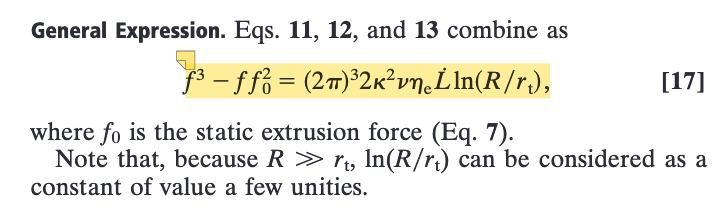

In [3]:
def Brochard_model(F, f0, l0):
    """
    Theoretical logarithmic model based on Eq. 17
    v = (F^3 +F*f0^2)/l0
    where f0 ~ f₀ (static force)
    and l0 ~ (2π)³2c²vₓLc (material/geometric parameters)
    """
    velocity = (F**3 - F*f0**2) / l0
    return velocity
    #return (F**3 - F*f0) / l0

<Figure size 2100x1500 with 0 Axes>

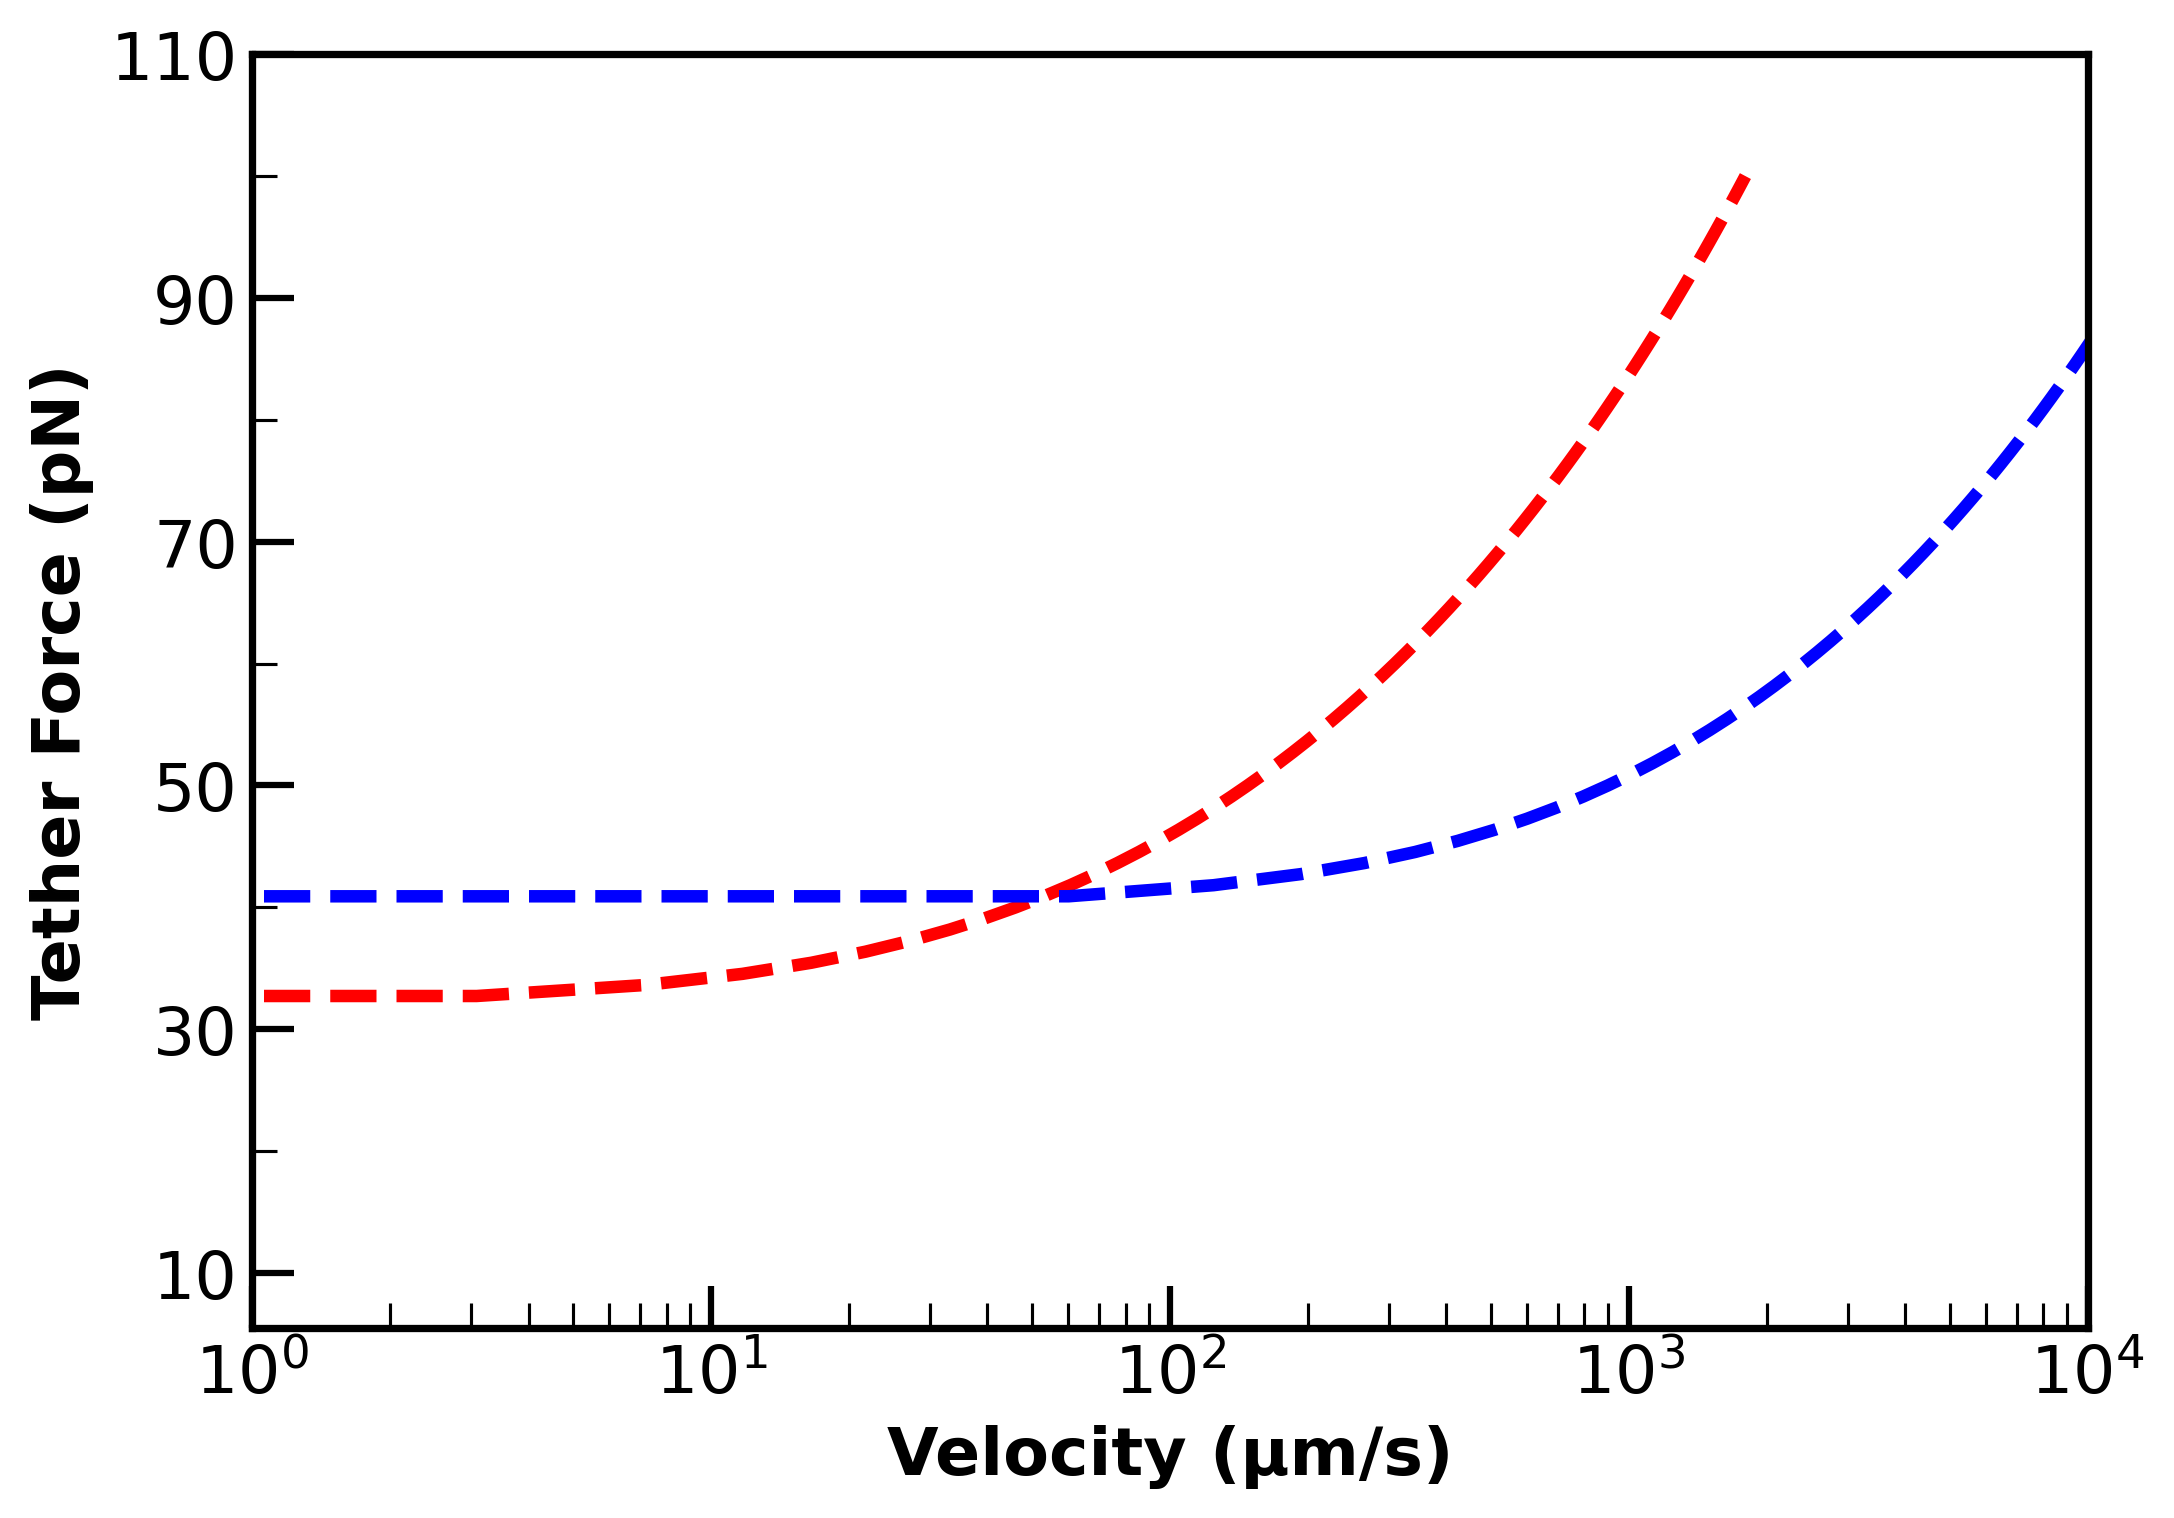

In [4]:
# 2. Tether Force vs Velocity (Scatter + Linear Trend)
import os
import scipy.stats as stats
from scipy.optimize import curve_fit

from matplotlib.ticker import MultipleLocator, LogLocator, AutoMinorLocator, FixedLocator
from matplotlib.ticker import LogLocator, LogFormatterMathtext
from matplotlib import gridspec

plt.figure(figsize=(7, 5), dpi=300)
plt.rcParams.update({
    'axes.linewidth': 1.75,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 10,  # Length of major ticks
    "ytick.major.size": 10,

    "xtick.minor.size": 6,  # Length of minor ticks
    "ytick.minor.size": 6,

    "xtick.major.width": 1.5,  # Width of major ticks
    "ytick.major.width": 1.5,

    "xtick.minor.width": 0.75,  # Width of minor ticks
    "ytick.minor.width": 0.75,
    "xtick.top": False,  # Enable top ticks
    "ytick.right": False,  # Enable right ticks
    # "ytick.left": True
})

# Main plot
fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

# 1. Scatter plot of all data points
force_plot = np.linspace(10,100,100)
popt_test=[32, 500]
popt_test_2 = [40, 50]
# ax.plot(Brochard_model(force_plot,*popt),force_plot, color='Black', linewidth = 3)
ax.plot(Brochard_model(force_plot,*popt_test),force_plot, color='red', linestyle='--', linewidth = 3)
ax.plot(Brochard_model(force_plot,*popt_test_2),force_plot, color='blue', linestyle='--', linewidth = 3)
# Formatting
ax.set_xlabel("Velocity (µm/s) calculated", fontsize=16, fontweight='bold')
ax.set_ylabel("Tether Force (pN)", fontsize=16, fontweight='bold')
ax.set_xscale('log')

plt.tight_layout()
plt.xlim(left = 10e-1)
ax.set_xlabel("Velocity (µm/s)", fontsize=16, fontweight='bold')
ax.set_ylabel("Tether Force (pN)", fontsize=16, fontweight='bold')
ax.set_xlim(1,10000)

# Fix y-axis tick labels
ax.tick_params(axis='x', labelsize=16, which='both', labelbottom=True)  # X-axis tick labels
ax.tick_params(axis='y', labelsize=16, which='both', labelleft=True, labelcolor='black', color='black')  # Y-axis tick labels


# Create nice y-axis tick values
y_ticks = [10,30,50,70,90,110]  # X MAJOR TICKS
ax.set_yticks(y_ticks)
ax.set_yticklabels([f'{tick:.0f}' for tick in y_ticks])
ax.yaxis.set_minor_locator(MultipleLocator(10))  # Minor ticks every 2 units

# Ensure y-axis is visible
ax.yaxis.set_visible(True)
ax.spines['left'].set_visible(True)

plt.show()



Experiments where taken on the following cells:
- Neytriphils
- Neurons
- OHC
- RBC


f0 = 41.81493914 pN, L0 = 88.94738515 pN 

In [16]:
# define variables
k = 50  # KbT curvature modulus
nu = 0.0015 # [m^-2] surface density of the cortical cytoskeleton , 
nu = 10e-1 #
eta = 0.01  # [Pa*s*m] viscosity of water at room temperature
R = 0.5e-6  # m radius of the cell; R>>r_t
r_t = 10e-9  # m radius of the tether
K = 294 # Kelvin
kbT = const.Boltzmann * K *k  # J

print (f'K: {k} kBT, nu: {nu} m^-2, eta: {eta} Pa*s*m, R: {R} m, r_t: {r_t} m')
print (f'KbT: {kbT} J')

eta_neutrophils = 10e-6
eta_neurons = 10e-8
eta_OHC = 10e-5
eta_RBC = 10e-4

K: 50 kBT, nu: 1.0 m^-2, eta: 0.01 Pa*s*m, R: 5e-07 m, r_t: 1e-08 m
KbT: 2.02955403e-19 J


In [22]:
def calculate_force_velocity(k, nu, eta, R, r_t):
    """
    Calculate force-velocity parameter from Brochard model.
    
    Parameters:
    k: KbT curvature modulus
    nu: surface density of the cortical cytoskeleton [m^-2]
    eta: viscosity [Pa*s*m]
    R: radius of the cell [m]
    r_t: radius of the tether [m]
    
    Returns:
    Force-velocity parameter [N*s*µm^-1]
    """
    F_vel = (2*np.pi)**3 * 2 * (k)**2 * nu * eta * np.log(R/r_t)
    return F_vel

F_vel = calculate_force_velocity(k, nu, eta_neutrophils, R, r_t)
velocity_pull = 100e-6
print (f'F_vel: {F_vel} [µm/s], eta: {eta_neutrophils} Pa*s*m')
print (f'Force at {velocity_pull*1e6} µm/s: {F_vel * velocity_pull*1e4} pN')



F_vel: 48.518907074401255 [µm/s], eta: 1e-05 Pa*s*m
Force at 100.0 µm/s: 48.518907074401255 pN


“The obtained value of $\eta_e \simeq 10^4$  $Pa\cdot s\cdot m$ ($ 100 pN \cdot s / \mu m$) sets a threshold velocity $L_c \sim 0.1  \mu m /s$. Beyond the determination of the membrane viscosity, our model also allows us to gain insight in the molecular mechanism of tether extrusion.” ([Brochard-Wyart et al., 2006, p. 4](zotero://select/library/items/ZEG6N9PJ)) ([pdf](zotero://open-pdf/library/items/T89EVTTW?page=4&annotation=7P7B7D2R))

In [27]:
# introduce velocity constant
velocity = 1e3 # µm/s pulling velocity
print (f'velocity: {velocity} µm/s')

velocity: 1000.0 µm/s


In [28]:
# introduce force fitting parameters
f0 = 40e-12  # N static force
f = 50-12 # N dynamic force

In [31]:
# caluclate tether radius
param = (f**3 - f * f0**2) / ( (2*np.pi)**3 * 2 * (k)**2 * nu * eta_neutrophils * velocity)
print (f'param: {param}')
r_t_calculated =  R * np.exp(-param)

print (f'Threshold Velocity: {param} µm/s, tether radius: {r_t_calculated} m')

param: 4.424265493546306
Threshold Velocity: 4.424265493546306 µm/s, tether radius: 5.991504833557406e-09 m
